In [13]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

In [14]:
# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Features
X = housing.data

# Target
y = housing.target

# Display first 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [15]:
print("Shape of Features:", X.shape)
print("Shape of Target:", y.shape)

Shape of Features: (20640, 8)
Shape of Target: (20640,)


In [16]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [17]:
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [18]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


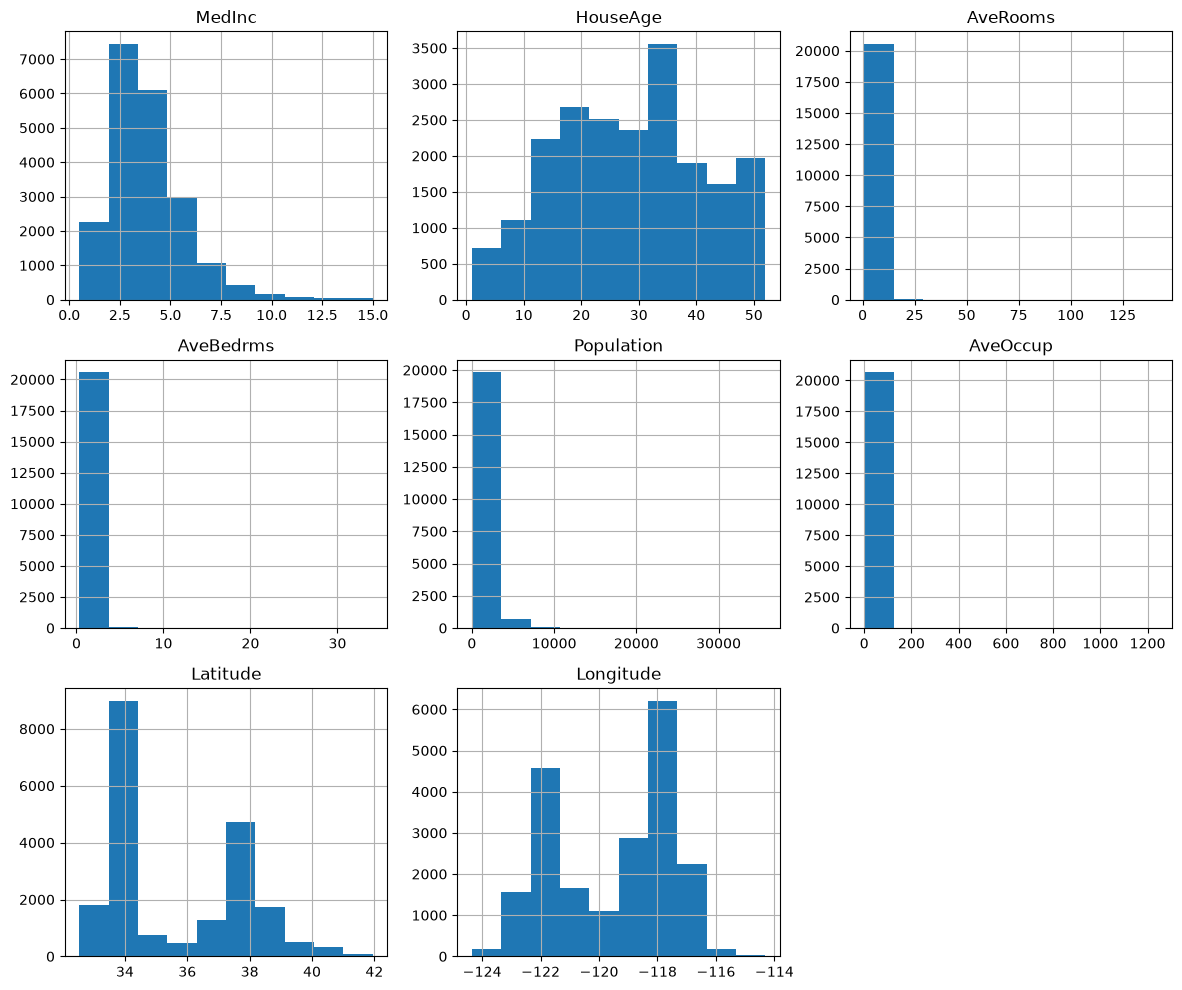

In [19]:
X.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [20]:
print(y.head())


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


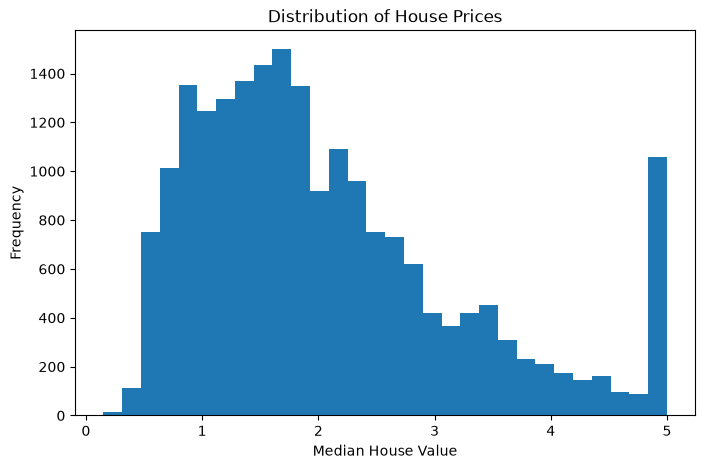

In [21]:
plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

In [22]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (16512, 8)
Testing Features: (4128, 8)
Training Target: (16512,)
Testing Target: (4128,)


In [23]:
# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [24]:
# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Display first 10 predictions
print(y_pred_lr[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [25]:
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate R² Score
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Results
-------------------------
RMSE: 0.7456
R² Score: 0.5758


In [26]:
# Perform 5-Fold Cross Validation
cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-Validation R² Scores:")
print(cv_scores)

print("\nAverage R² Score:", cv_scores.mean())

Cross-Validation R² Scores:
[0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]

Average R² Score: 0.611483995256099


In [27]:
# Create Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [28]:
# Predict on test data
y_pred_dt = dt_model.predict(X_test)

In [29]:
# Calculate RMSE
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

# Calculate R² Score
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("----------------------")
print(f"RMSE: {dt_rmse:.4f}")
print(f"R² Score: {dt_r2:.4f}")

Decision Tree Results
----------------------
RMSE: 0.7093
R² Score: 0.6161


In [30]:
# Training Score
train_score = dt_model.score(X_train, y_train)

# Testing Score
test_score = dt_model.score(X_test, y_test)

print("Training R² Score:", train_score)
print("Testing R² Score:", test_score)

Training R² Score: 1.0
Testing R² Score: 0.6160675721345087


In [31]:
# Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [32]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train the model
grid_search.fit(X_train, y_train)

print("Grid Search Completed!")

Grid Search Completed!


In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation Score:
0.710309098042767


In [34]:
best_model = grid_search.best_estimator_

print(best_model)


DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, random_state=42)


In [35]:
# Predict using the tuned model
y_pred_best = best_model.predict(X_test)

In [36]:
# Calculate RMSE
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

# Calculate R² Score
best_r2 = r2_score(y_test, y_pred_best)

print("Tuned Decision Tree Results")
print("---------------------------")
print(f"RMSE: {best_rmse:.4f}")
print(f"R² Score: {best_r2:.4f}")

Tuned Decision Tree Results
---------------------------
RMSE: 0.6391
R² Score: 0.6883


In [37]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        best_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        best_r2
    ]
})

results


,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Decision Tree,0.709301,0.616068
2,Tuned Decision Tree,0.639065,0.688338


In [38]:
# Save the best model
joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [39]:
# Load the saved model
loaded_model = joblib.load("best_model.pkl")

print("Model loaded successfully!")


Model loaded successfully!


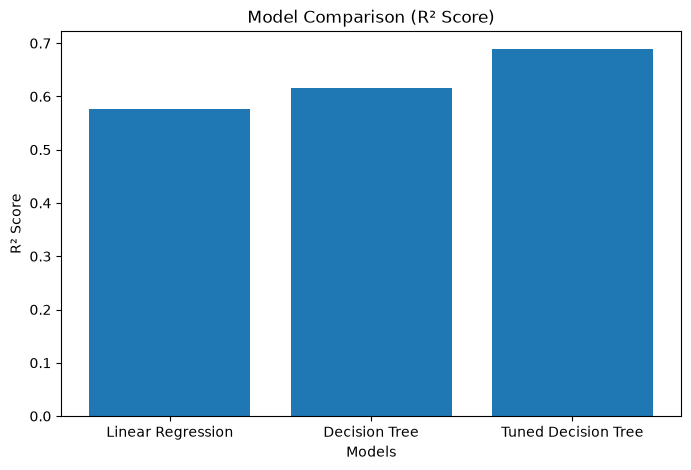

In [40]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

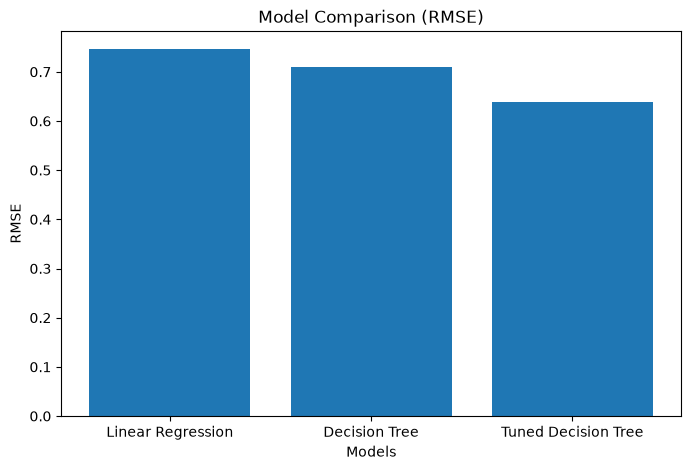

In [41]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

# Conclusion

In this project, three regression models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Tuned Decision Tree Regressor

Cross-validation was used to obtain a more reliable estimate of model performance.

GridSearchCV was applied to optimize the Decision Tree hyperparameters, helping reduce overfitting and improve generalization.

The tuned Decision Tree achieved better performance than the baseline model, demonstrating the importance of hyperparameter tuning in machine learning.